# Problems Notebook
---

This notebook contains my work of the assessment in Applied Statistics module in the Higher Diploma in Data Analytics course. 

The notebook covers four main problems: 

* **Problem 1: Extending the Lady Tasting Tea**
* **Problem 2: Normal Distribution**
* **Problem 3: t-Test**
* **Problem 4 : ANOVA**

To address the problems above, I will use Python for simulation and visualization, supported by the material covered in lectures and relevant online references.

To begin, I will import the necessary libraries. These will be used throughout the analysis for the parts of the problems.

In [130]:
# Import necessary libraries

# for mathematical functions
# see https://docs.python.org/3/library/math.html
import math

# for combinatorial functions
# see https://docs.python.org/3/library/itertools.html
import itertools

# for random number generation
# see https://www.w3schools.com/python/module_random.asp
import random

# for numerical operations
# see https://www.w3schools.com/python/numpy/numpy_intro.asp
import numpy as np

# for data visualization and plotting
# see https://www.w3schools.com/python/matplotlib_pyplot.asp
import matplotlib.pyplot as plt

# for statistical functions
# see https://www.geeksforgeeks.org/python/scipy-stats/
import scipy.stats as stats

# statistical models
#https://www.geeksforgeeks.org/data-science/statsmodel-library-tutorial/
import statsmodels as sm

Let's go through each of the problem.

## Problem 1: Extending the Lady Tasting Tea:
---

Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

### Solution to the Problem 1
---

In the [**Original Lady Tasting Tea**](https://en.wikipedia.org/wiki/Lady_tasting_tea) experiment devised by [Ronald Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher) we had **8 cups: 4 tea first and 4 milk first.** The Lady's task was to select the correct 4 milk first cups. The experiment asked whether the Lady could tell if the milk was added before the tea.

In this Extended experiment, we have:

* **Total cups $(n)$** : 12
* **Composition** : 8 Tea-first and 4 milk-first
* **Participant task $(k)$ :** Identify the 8 tea-first cups. 


The primary selection is that participant selects a set of 8 cups and they automatically leave a set of 4 unselected cups which will be labelled as tea-first. 

We only need to track the accuracy of 8-cup selection, because a perfect match in that set logically requires a perfect match in the 4-cup set, which will also be checked. 

The core probablility is calculated using [combination](https://en.wikipedia.org/wiki/Combination) which is the number of ways to choose a subset from a larger set where the order does not matter. 

It is written and calculated as [factorial](https://en.wikipedia.org/wiki/Factorial) notation: 

$\binom{n}{k} = \frac{n!}{k!(n-k)!}$




**Total possible Outcome**

The mathematical explanation below is showing the total number of unique ways the participant can choose any 4 cups from the 12 total cups of tea, and the same 8 cups from the 12 total cups of tea. 


$
\binom{12}{4}
= \frac{12!}{4!(12-4)!}
= \frac{12!}{4!8!}
= \frac{479,001,600}{24 \times 40,320}
= \frac{479,001,600}{967,680}
= 495
$

$
\binom{12}{8}
= \frac{12!}{8!(12-8)!}
= \frac{12!}{8!4!}
= \frac{479{,}001{,}600}{40{,}320 \times 24}
= \frac{479{,}001{,}600}{967{,}680}
= 495
$

It does not matter whether we ask how many ways to pick 4 milk-first or how many ways to pick 8 tea-first, the result is still the same: 495.

This is because choosing 4 cups **is the same** as choosing 8 cups that **are not** selected. 

**The Single Correct Outcome** 

To get a perfect score, which means that the participant must select 8 cups that exactly matches the 8 cups that actually have tea-first tea. There is only one way to achieve this. 

$\
P(\text{Perfect Score})
= \frac{\text{Number of ways to get all 8 milk-first correct}}
       {\text{Total number of ways to select 8 cups}}
= \frac{1}{495}
\approx 0.00202
$


In this scenario, a perfect score means the chance of that result occurring randomly is **0.202%** which is 1 in 495 chance. 

For this experiment, we set up a [statistical hypotesis](https://www.datacamp.com/tutorial/hypothesis-testing) test. We assume that the [**Null Hypothesis $(H_0)$**](https://en.wikipedia.org/wiki/Null_hypothesis) is true: the participant is selecting cups **at random** and has **no special ability**. 

The [**Altern Hypothesis $(H_A)$**](https://en.wikipedia.org/wiki/Alternative_hypothesis) is that the participant **does have** the ability.

The objective is to calculate and simulate the probability [($p$-value)](https://en.wikipedia.org/wiki/P-value) of getting a perfect score purely by chance if $(H_0)$ is true. I will use this probability to decide whether there is sufficient evidence to reject the *Null Hypothesis* in favor of the *Alternative Hypothesis*. 

Let's go through this using Python. 

#### Mathematical Concepts
---


I use [`math.comb(n, k)`](https://docs.python.org/3/library/math.html#math.comb) to find the total number of possible ways the participant could select the cups, which determines the theoretical probability (or $p$-value) of a perfect guess by chance ($1 / \text{Total Ways}$). 

##### Cups of Tea in Original Experiment
---

Let's see the original experiment first. 

In [131]:

# Number of cups of tea. All cups are identical. 
num_cups= 8

# Number of cups with tea first
num_tea_first = 4

# Number of cups with milk first
num_milk_first= 4

In [132]:
# Number of ways to select 8 cups from 12
n = num_cups
k = num_tea_first

tea_ways_org = math.comb(n, k)

print(f'Number of ways to select cups is {tea_ways_org}')

Number of ways to select cups is 70


The original Lady Tasting Tea experiment has $n$ = 8 total cups, and $k$ = 4 were to be selected (4 milk-first and 4 tea-first). 

The total number of unique ways to select 4 cups from 8 is:


$
\binom{8}{4}
= \frac{8!}{4!(8-4)!}
= \frac{8!}{4!4!}
= 70
$


The probability of selecting the single correct combination by chance is $\frac{1}{70}$ ≈ **0.01429** which is about **1.429%** chance. 

##### Cups of Tea in Extended Experiment
---

The goal of this experiment is to test the participant's ability to identify 8 tea-first cups from a total of 12 cups (where the remaining 4 are milk first). We calculate the total number of unique ways the participant could make their selection (the denominator for our probability).

**Initial Calculation: Combinatorial Symmetry**

The experiment requires the participant to identify the $k=8$ tea-first cups out of $N=12$ total cups. The number of ways to choose 8 cups is the same as the number of ways to choose the remaining 4 cups.

In [133]:
# Number of cups of tea. All cups are identical. 
num_cups_ex = 12

# Number of cups with tea first
num_tea_first_ex = 8

# Number of cups with milk first
num_milk_first_ex = 4

In [134]:
# Number of ways to select 8 cups from 12

tea_ways_ex = math.comb(num_cups_ex, num_tea_first_ex)

print(f'Number of ways to select cups is {tea_ways_ex}')

Number of ways to select cups is 495


In [135]:
# number of ways to select 4 cups from 12
milk_ways_ex = math.comb(num_cups_ex, num_milk_first_ex)

print(f'Number of ways to select cups is {milk_ways_ex}')

Number of ways to select cups is 495


Both results shows 495 which is **1 in 495 chances**. 
This means the probability of a perfect score (if guessing randomly) is $\mathbf{1 \text{ in } 495}$ (or $0.202\%$).

Although these results might not look ***exaclty*** the same - **if we choose 8 cups to have tea first, it leaves us with remaining 4 cups with milk. If we choose 4 cups with milk, we will have 8 cups remaining** - we can confirm they are mathematically equivalent.  



Let's go through the calculations carefully. 

##### Exploring the Combinatorial Formula
---


**[Permutation (Order Matters) and Combination (Order does NOT Matter)](https://www.geeksforgeeks.org/maths/permutations-and-combinations/)**

We first calculate the number of ordered ways to select 8 cups from 12. This is a [permutation](https://www.geeksforgeeks.org/maths/permutation/), $P(12, 8)$.

We can demonstrate the result using the following calculations to select the 8 tea-first cups and confirm the mathematical equivalence as to selecting 4 milk-first, $\binom{12}{4} = \binom{12}{8}$.

Let's label the 12 cups of tea from the extened experiment `1`, `2`, `3`, `4`, `5`, `6`, `7`, `8`, `9`, `10`, `11`, `12`. 

We select 8 cups to have tea poured in first.

For example, we might select `1`, `2`, `4`, `6`, `9`, `10`, `11` and `12`.

Visualize having eight saucers where we place eight of the cups.

How many ways are there to select 8 cups from 12?

Cups: `1 2 3 4 5 6 7 8 9 10 11 12`

Saucers: `_ _ _ _ _ _ _ _`

In [136]:
# Total number of ways of selecting 8 cups from 12, keeping them in order.
ways_ordered_tea = 12 * 11 * 10 * 9 * 8 * 7 * 6 * 5

# Show.
ways_ordered_tea

19958400

The multiplication $12 \times 11 \times 10 \times 9 \times 8 \times 7 \times 6 \times 5$ starts with the total number of options (12) and multiplies it by the decreasing number of remaining options for each of the 8 choices:

* 12 options for the first cup selected
* 11 options for the second cup selected
* ...
* 5 options for the eighth cup selected.

This results in a large number: $12 \times 11 \times 10 \times 9 \times 8 \times 7 \times 6 \times 5 = \mathbf{19,958,400}$ if the order of selection would matter.

**Combination (Order Does NOT Matter)**

In the Lady Tasting Tea analysis the order **doesn't matter**. If cups `1`, `2`, `4`, `6`, `9`, `10`, `11` and `12`. are selected in order it is the same result as if `12`, `11`, `9`, `10`, `2`, `6`, `4` and `1`. were selected, or any other permutation.

`1 2 4 6 9 10 11 12`

`12 11 9 10 2 6 4`

`_ _ _ _ _ _ _ _`

This calculation finds the number of ways to pick 8 cups 

In [137]:
# No of ways of shuffling 8 cups.
no_shuffles_tea = 8 * 7 * 6 * 5 * 4 * 3 * 2 * 1

# Show.
no_shuffles_tea

40320

The total number of ways the 8 selected cups could be shuffled is $40320$.

To find the correct number of unordered combinations, we need to divide the total number of ways to pick 8 cups by the number of ways to shuffle them.

In [138]:
# No of combinations ups with tea.
no_comb_tea = ways_ordered_tea // no_shuffles_tea

# Show.
no_comb_tea

495

$\binom{12}{8} = \frac{\text{Ways to select } 8 \text{ ordered cups}}{\text{Ways to shuffle the } 8 \text{ selected cups}} = \frac{12 \times 11 \times \dots \times 5}{8!} = \frac{19,958,400}{40,320} = \mathbf{495}$

**Let's check if we get the same result selecting 4 cups to have milk first.**

Again, we have our labeled 12 cups of tea `1`, `2`, `3`, `4`, `5`, `6`, `7`, `8`, `9`, `10`, `11`, `12`. 

But now we select 4 cups to have milk in first. We start again, so we still have 12 cups.

Let's select `3`, `5`, `7`, and `8`.

We place them on the other four saucers where we place four cups on, where we guess the milk is first. 

How many ways are there to select 4 cups from 12?

Cups: `1 2 3 4`

Saucers: `_ _ _ _`

In [139]:
# Total number of ways of selecting 4 cups from 12, keeping them in order.
ways_ordered_milk = 12 * 11 * 10 * 9

# Show.
ways_ordered_milk

11880

The total number of ways to select 4 cups is $11880$

And again, the order doesn't matter. 

In [140]:
# No of ways of shuffling four cups.
no_shuffles_milk = 4 * 3 * 2 * 1

# Show.
no_shuffles_milk

24

The total number of ways to pick 8 selected cups that could be internally shuffled is $24$.

In [141]:
# No of combinations milk.
no_combs_ex = ways_ordered_milk // no_shuffles_milk

# Show.
no_combs_ex

495

$$\binom{12}{4} = \frac{\text{Ways to select } 4 \text{ ordered cups}}{\text{Ways to shuffle the } 4 \text{ selected cups}} = \frac{11,880}{24} = \mathbf{495}$$

There are 495 ways to select 8 cups with tea, which is similar as choosing 4 cups with milk. It is just viewed from the opposite perspective.

Python provides the function [`math.factorial`]((https://docs.python.org/3.12/library/math.html#math.factorial)) for computing factorials.  

Factorials are the building block of many counting formulas, including the
number of ways to arrange $(n)$ distinct items (permutations).


The factorial of a non-negative integer **$n$**, denoted by **$n!$**, is the product of all positive integers less than or equal to $n$. It is used to calculate the total number of ways to arrange $n$ distinct items in order, also known as the number of **permutations** of $n$ elements

Mathematically denoted as `n!`.

Multiply all positive integers from `n` down to 1.


`n! = n x (n - 1) x (n - 2) x ... x 1`

e.g. `5! = 5 x 4 x 3 x 2 x 1 = 120`

In [142]:
# Number of cups of tea in total.
n = 12

In [143]:
# Number of cups of tea with milk in first.
k = 8

In [144]:
# Twelve factorial.
math.factorial(n)

479001600

In [145]:
# Four factorial.
math.factorial(k)

40320

In [146]:
# Four factorial.
math.factorial(n - k)

24

In [147]:
# No of ways of selecting k objects from n without replacement and without order.
math.factorial(n) // (math.factorial(k) * math.factorial(n - k))

495

This calculation definitively confirms that there are $\mathbf{495}$ $\mathbf{unique}$ $\mathbf{ways}$ for the participant to select 4 cups from the total of 12.

#### Ordering of Results
---

To list all possible selections of cups, we use Python’s
[`itertools.combinations`](https://docs.python.org/3/library/itertools.html#itertools.combinations).

- The function `combinations(iterable, r)` returns all different ways of picking
  `r` items from `iterable` **without regard to order**.
- In this experiment, `iterable` is the set of cup labels and `r` is the number
  of cups the participant claims were poured milk-first.

Each element returned by `combinations` represents **one possible guess pattern**
the participant could make.

Generate the possibilities 

We first label each cup with a simple integer ID (0, 1, 2, …). Then we use
`itertools.combinations` to generate **every possible set of cups** that could
be identified as “milk first”. This gives us the full space of outcomes under
random guessing.

In [148]:
# the cup labels
# integers from 0 up to (but not including) num_cups_ex
# if num_cups_ex = 12, we get [0, 1, 2, ..., 11]
labels = list(range(num_cups_ex))

# show
labels



[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [149]:
# Show the different ways of selecting no_cups_milk_first out of no_cups cups of tea.
combs = list(itertools.combinations(labels, num_tea_first_ex))

# Show.
# all combinations (the entire sample space under random guessing).
combs

[(0, 1, 2, 3, 4, 5, 6, 7),
 (0, 1, 2, 3, 4, 5, 6, 8),
 (0, 1, 2, 3, 4, 5, 6, 9),
 (0, 1, 2, 3, 4, 5, 6, 10),
 (0, 1, 2, 3, 4, 5, 6, 11),
 (0, 1, 2, 3, 4, 5, 7, 8),
 (0, 1, 2, 3, 4, 5, 7, 9),
 (0, 1, 2, 3, 4, 5, 7, 10),
 (0, 1, 2, 3, 4, 5, 7, 11),
 (0, 1, 2, 3, 4, 5, 8, 9),
 (0, 1, 2, 3, 4, 5, 8, 10),
 (0, 1, 2, 3, 4, 5, 8, 11),
 (0, 1, 2, 3, 4, 5, 9, 10),
 (0, 1, 2, 3, 4, 5, 9, 11),
 (0, 1, 2, 3, 4, 5, 10, 11),
 (0, 1, 2, 3, 4, 6, 7, 8),
 (0, 1, 2, 3, 4, 6, 7, 9),
 (0, 1, 2, 3, 4, 6, 7, 10),
 (0, 1, 2, 3, 4, 6, 7, 11),
 (0, 1, 2, 3, 4, 6, 8, 9),
 (0, 1, 2, 3, 4, 6, 8, 10),
 (0, 1, 2, 3, 4, 6, 8, 11),
 (0, 1, 2, 3, 4, 6, 9, 10),
 (0, 1, 2, 3, 4, 6, 9, 11),
 (0, 1, 2, 3, 4, 6, 10, 11),
 (0, 1, 2, 3, 4, 7, 8, 9),
 (0, 1, 2, 3, 4, 7, 8, 10),
 (0, 1, 2, 3, 4, 7, 8, 11),
 (0, 1, 2, 3, 4, 7, 9, 10),
 (0, 1, 2, 3, 4, 7, 9, 11),
 (0, 1, 2, 3, 4, 7, 10, 11),
 (0, 1, 2, 3, 4, 8, 9, 10),
 (0, 1, 2, 3, 4, 8, 9, 11),
 (0, 1, 2, 3, 4, 8, 10, 11),
 (0, 1, 2, 3, 4, 9, 10, 11),
 (0, 1, 2, 3, 5, 6, 7, 8)

This code generates every possible way a participant could randomly guess the 8 tea-first cups out of the 12. Since order does not matter, we use `itertools.combinations`. The output list `combs` contains all
$\binom{12}{8} = 495$ unique guesses, representing the entire sample space under random guessing.

Now, we check the probability of selecting one particular combination by pure random guessing.

In [150]:
# Number of combinations.
len(combs)

495

In [151]:
# Probability of selecting one particular combination.
# Since all combinations are equally likely, the probability is 1 divided by the total number of combinations

1/len(combs)

0.00202020202020202

In [152]:
# Select eight cups at random to put tea in first.
# https://docs.python.org/3/library/random.html#random.sample
labels_tea = random.sample(labels, 8)

# Sort the chosen labels in place so they are easier to read.
labels_tea.sort()

# Show.
labels_tea

[0, 1, 2, 3, 5, 7, 10, 11]

In [153]:
# Turn labels_tea into a set.
# Uses: https://docs.python.org/3/tutorial/datastructures.html#sets
set(labels_tea)

{0, 1, 2, 3, 5, 7, 10, 11}

In [154]:
# Calculate the overlap between each element of combs and labels_tea.

no_overlaps = []


#loop through each combination in combs.
for comb in combs:
  # Turn comb into a set.
  s1 = set(comb)
  # Turn labels_tea into a set.
  s2 = set(labels_tea)
  # Figure out where they overlap.
  overlap = s1.intersection(s2)
  # Show the combination and the overlap.
  print(comb, len(overlap), overlap)
  # Append overlap to no_overlaps.
  no_overlaps.append(len(overlap))

(0, 1, 2, 3, 4, 5, 6, 7) 6 {0, 1, 2, 3, 5, 7}
(0, 1, 2, 3, 4, 5, 6, 8) 5 {0, 1, 2, 3, 5}
(0, 1, 2, 3, 4, 5, 6, 9) 5 {0, 1, 2, 3, 5}
(0, 1, 2, 3, 4, 5, 6, 10) 6 {0, 1, 2, 3, 5, 10}
(0, 1, 2, 3, 4, 5, 6, 11) 6 {0, 1, 2, 3, 5, 11}
(0, 1, 2, 3, 4, 5, 7, 8) 6 {0, 1, 2, 3, 5, 7}
(0, 1, 2, 3, 4, 5, 7, 9) 6 {0, 1, 2, 3, 5, 7}
(0, 1, 2, 3, 4, 5, 7, 10) 7 {0, 1, 2, 3, 5, 7, 10}
(0, 1, 2, 3, 4, 5, 7, 11) 7 {0, 1, 2, 3, 5, 7, 11}
(0, 1, 2, 3, 4, 5, 8, 9) 5 {0, 1, 2, 3, 5}
(0, 1, 2, 3, 4, 5, 8, 10) 6 {0, 1, 2, 3, 5, 10}
(0, 1, 2, 3, 4, 5, 8, 11) 6 {0, 1, 2, 3, 5, 11}
(0, 1, 2, 3, 4, 5, 9, 10) 6 {0, 1, 2, 3, 5, 10}
(0, 1, 2, 3, 4, 5, 9, 11) 6 {0, 1, 2, 3, 5, 11}
(0, 1, 2, 3, 4, 5, 10, 11) 7 {0, 1, 2, 3, 5, 10, 11}
(0, 1, 2, 3, 4, 6, 7, 8) 5 {0, 1, 2, 3, 7}
(0, 1, 2, 3, 4, 6, 7, 9) 5 {0, 1, 2, 3, 7}
(0, 1, 2, 3, 4, 6, 7, 10) 6 {0, 1, 2, 3, 7, 10}
(0, 1, 2, 3, 4, 6, 7, 11) 6 {0, 1, 2, 3, 7, 11}
(0, 1, 2, 3, 4, 6, 8, 9) 4 {0, 1, 2, 3}
(0, 1, 2, 3, 4, 6, 8, 10) 5 {0, 1, 2, 3, 10}
(0, 1, 2, 3, 4, 6, 8, 1

This code calculates how many cups the participant would identify correctly for every possible random guess in the sample space. For each of the 495 possible combinations (`combs`) of 8 tea-first cups, we compare that guess to the actual set of tea-first cups (`labels_tea`). By converting both the guess (`comb`) and the true labels (`labels_tea`) to sets, we can use set intersection to count how many cups overlap. In other words, how many the participant would get correct if that guess were made. Each overlap count is stored in `no_overlaps`, producing a list of 495 numbers that represent the distribution of correct guesses under random guessing.

In [155]:
# Show the overlaps.
print(no_overlaps)

[6, 5, 5, 6, 6, 6, 6, 7, 7, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 5, 6, 6, 6, 6, 7, 6, 7, 7, 7, 7, 8, 6, 6, 7, 7, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 5, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 6, 5, 6, 5, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6, 6, 7, 5, 5, 6, 6, 6, 6, 7, 7, 6, 5, 5, 6, 6, 5, 6, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 6, 5, 6, 5, 4, 5, 5, 5, 5, 6, 4, 4, 5, 5, 5, 5, 6, 6, 5, 4, 4, 5, 5, 4, 5, 5, 5, 6, 6, 5, 6, 5, 4, 4, 5, 5, 4, 5, 4, 5, 5, 5, 6, 

In [156]:
# Count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# Show.
counts

(array([4, 5, 6, 7, 8]), array([ 70, 224, 168,  32,   1], dtype=int64))

Let's create a figure to visualise the distribution of overlap counts.

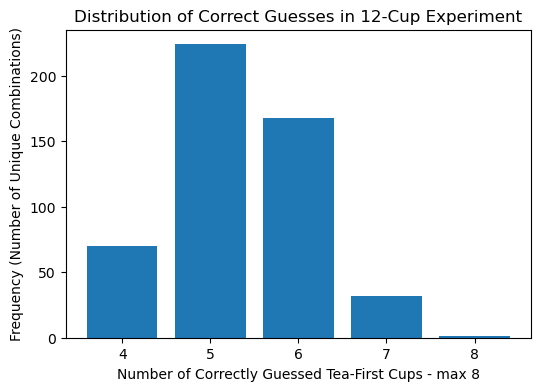

In [157]:
# Create a figure.
# Bar chart where the x-axis is "number of correctly guessed cups"
# and the y-axis is "how many combinations achieve that many correct cups".
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1])

# Set the title for the x-axis 
ax.set_xlabel("Number of Correctly Guessed Tea-First Cups - max 8")

# Set the title for the y-axis 
ax.set_ylabel("Frequency (Number of Unique Combinations)")

# Settitle for the plot
ax.set_title("Distribution of Correct Guesses in 12-Cup Experiment")

plt.show()

The bar chart shows the **exact distribution** of how many tea-first cups a
participant would guess correctly **if she were guessing at random** in the
12-cup version of the Lady Tasting Tea experiment.

There are 12 cups in total, 8 of which are truly tea-first.  
The participant must guess which 8 cups these are.

Because there are $\binom{12}{4} = \mathbf{495}$ possible guesses, and all are equally
likely under random guessing, we can check how many guesses achieve each
possible number of correct cups:

| Correct cups guessed | Count of combinations |
|----------------------|-----------------------|
| 4 | 70 |
| 5 | **224** |
| 6 | 168 |
| 7 | 32 |
| 8 | 1 |


This distribution tell us that **most common random outcome** is getting **5 correct cups**.
This happens in **224 out of 495** possible guesses (about 45%).


What about other probabilities? 

In [158]:
# Calculate the distribution of correct guesses 
total = math.comb(num_cups_ex, num_tea_first_ex)

# check counts for k correct guesses
dist_counts = {}

for k in range(num_tea_first_ex + 1): # k - number of tea-first cups guessed correctly
    
    # the participant is guessing number of tea-first cups correctly
    # if k of them are correct tea-first cups
    # then the remaining (num_milk_first_ex - k) must be milk-first cups guessed correctly

   if 0 <= num_tea_first_ex - k <= num_milk_first_ex:
        dist_counts[k] = (
            math.comb(num_tea_first_ex, k) *
            math.comb(num_milk_first_ex, num_tea_first_ex - k)
        )

# display table
print(f"| {'Correct':^7} | {'Count':^7} | {'Probability':^12} |")
print(f"|{'-'*9}|{'-'*9}|{'-'*14}|")

for k in sorted(dist_counts.keys()): # sort keys in ascending order # https://www.geeksforgeeks.org/python/python-sort-python-dictionaries-by-key-or-value/
    count = dist_counts[k]
    prob = count / total
    print(f"| {k:^7} | {count:^7} | {prob:^12.4f} |") # https://docs.python.org/3/tutorial/inputoutput.html

| Correct |  Count  | Probability  |
|---------|---------|--------------|
|    4    |   70    |    0.1414    |
|    5    |   224   |    0.4525    |
|    6    |   168   |    0.3394    |
|    7    |   32    |    0.0646    |
|    8    |    1    |    0.0020    |


From the distribution we can see that most random guesses stay around the middle values:

- Getting **5 correct** is the most common outcome (224 combinations, about 45%).
- Getting **6 correct** is less common (168 combinations, about 34%).
- Getting **7 correct** is rare (32 combinations, about 6.5%).
- Getting **all 8 correct** is extremely rare  
  (only **1** combination out of 495 ≈ **0.2%**).

Because the participant must identify all **8 tea-first cups** (or equivalently,
all **4 milk-first cups**), these numbers describe exactly what we expect under
the null hypothesis of exact guessing.




Let’s switch everything to the original 8-cup experiment to check the probability 

In [159]:

# Calculate the distribution of correct guesses 
total = math.comb(num_cups, num_tea_first)

# check counts for k correct guesses
dist_counts = {}

for k in range(num_tea_first + 1): # k - number of tea-first cups guessed correctly
    
    # the participant is guessing number of tea-first cups correctly
    # if k of them are correct tea-first cups
    # then the remaining (num_milk_first - k) must be milk-first cups guessed correctly

   if 0 <= num_tea_first - k <= num_milk_first:
        dist_counts[k] = (
            math.comb(num_tea_first, k) *
            math.comb(num_milk_first, num_tea_first - k)
        )

# display table
print(f"| {'Correct - Original'} | {'Count - Original'} | {'Probability - Original'} |")
print(f"|{'-'*20}|{'-'*18}|{'-'*24}|")

for k in sorted(dist_counts.keys()): # sort keys in ascending order # https://www.geeksforgeeks.org/python/python-sort-python-dictionaries-by-key-or-value/
    count = dist_counts[k]
    prob = count / total
    print(f"| {k:^18} | {count:^16} | {prob:^22.4f} |") # https://docs.python.org/3/tutorial/inputoutput.html


| Correct - Original | Count - Original | Probability - Original |
|--------------------|------------------|------------------------|
|         0          |        1         |         0.0143         |
|         1          |        16        |         0.2286         |
|         2          |        36        |         0.5143         |
|         3          |        16        |         0.2286         |
|         4          |        1         |         0.0143         |


##### Comparison with Fisher’s original 8-cup experiment
---

In Fisher’s design (4 milk-first, 4 tea-first):

The chance of a perfect result (4/4) is  
  $
  \frac{1}{\binom{8}{4}} = \frac{1}{70} \approx 1.4\%.
  $

In this extended 12-cup version (4 milk-first, 8 tea-first):

The chance of a perfect result (all 8 tea-first correct) is  
  $
  \frac{1}{\binom{12}{4}} = \frac{1}{495} \approx 0.2\%.
  $


It is **much harder** for a participant to get a perfect score by guessing.

Therefore, a perfect result in the 12-cup version is **even stronger evidence** of real sensitivity to the pouring order than in the 8-cup experiment.

Because the experiment itself is stricter, we do **not** need to relax the usual p-value threshold.

##### Simulation of the 'lady tasting tea' experiment.
---

The function below simulates the experiment under random guessing:

1. Randomly choose which cups are **true tea-first**.
2. Randomly choose which cups the participant **guesses** are tea-first.
3. Count how many of the 8 true tea-first cups were guessed correctly.
4. Repeat this process many times to approximate the distribution of possible outcomes under guessing.

In [160]:
trials = 50000  # number of simulated shuffles
random.seed(42) # for reproducibility

n = num_cups_ex
k = num_tea_first_ex

# Simulation function
def simulate_correct_counts(n, k, trials):
    correct_counts = []  # list to store how many cups are correct each time

    for i in range(trials):
        # 1: Randomly assign which cups are tea first
        true_tea = set(random.sample(range(n), k))

        # 2: Participant randomly guesses which k cups are tea first
        guess_tea = set(random.sample(range(n), k))

        # 3: Count how many cups were guessed correctly
        num_correct = len(true_tea.intersection(guess_tea)) # intersection gives common elements between two sets
        
        # 4: Store the result
        correct_counts.append(num_correct)

    return correct_counts


In [161]:
# Run simulation for both experiments
correct_8 = simulate_correct_counts(num_cups, num_tea_first, trials)
correct_12 = simulate_correct_counts(num_cups_ex, num_tea_first_ex, trials)

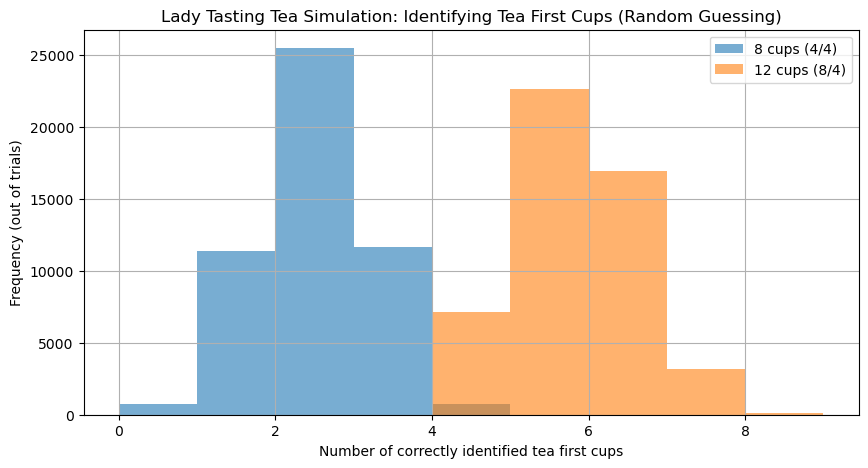

Probability of perfect guessing (8 cups):  0.014380 ≈ 1/70
Probability of perfect guessing (12 cups): 0.142500 ≈ 1/495


In [162]:
# Plot results

plt.figure(figsize=(10, 5))

plt.hist(correct_8, bins=range(num_tea_first + 2), alpha=0.6, label='8 cups (4/4)')
plt.hist(correct_12, bins=range(num_tea_first_ex + 2), alpha=0.6, label='12 cups (8/4)')

plt.xlabel("Number of correctly identified tea first cups")
plt.ylabel("Frequency (out of trials)")
plt.title("Lady Tasting Tea Simulation: Identifying Tea First Cups (Random Guessing)")
plt.legend()
plt.grid(True)
plt.show()


# Print probabilities of perfect guessing
p_all_correct_8 = correct_8.count(num_milk_first) / trials
p_all_correct_12 = correct_12.count(num_milk_first_ex) / trials

print(f"Probability of perfect guessing (8 cups):  {p_all_correct_8:.6f} ≈ 1/{math.comb(8,4)}")
print(f"Probability of perfect guessing (12 cups): {p_all_correct_12:.6f} ≈ 1/{math.comb(12,4)}")



The histogram displays the distribution of correct identifications expected
under random guessing for two experimental designs:

- the **original 8-cup experiment** (4 tea-first / 4 milk-first)  
- the **extended 12-cup experiment**, focusing on identifying **8 tea-first cups**

In both designs, most simulated trials produce **middle-range scores**:

- around **2-3 correct** in the 8-cup version  
- around **5–6 correct** in the 12-cup version  

High scores occur far less frequently, and **perfect scores are extremely rare**.

Let's recap. A perfect result means:

- **4/4 tea-first correct** in the 8-cup test  
- **8/8 tea-first correct** in the 12-cup test  

Under random guessing, these outcomes occur with probabilities:

$
P(\text{perfect in 8 cups}) = \frac{1}{\binom{8}{4}} = \frac{1}{70} \approx 1.4\%
$

$
P(\text{perfect in 12 cups}) = \frac{1}{\binom{12}{4}} = \frac{1}{495} \approx 0.2\%
$

The simulation matches these theoretical values: in tens of thousands of simulated
trials, only a tiny bit can achieve a perfect score.



Because perfect scores are so rare under $(H_0)$, observing one in a real experiment would have an extremely small p-value:

- **8-cup experiment:**  
  $(p \approx 0.014 < 0.05)$ → strong evidence against $(H_0)$

- **12-cup experiment:**  
  $(p \approx 0.002 < 0.01)$ → *even stronger* evidence against $(H_0)$

This allows us to confirm:

* If a participant correctly identifies **all tea-first cups**, this result would be highly unlikely under random guessing.  
* Therefore a perfect score provides strong evidence in favor of $(H_A)$: the participant likely has genuine ability to distinguish the pouring order.




**Conclusion on P-value Threshold Adjustment**

The decision in this hypothesis test is determined by comparing the calculated $p$-value to the predetermined [significance level](https://en.wikipedia.org/wiki/Statistical_significance) (${\alpha}$), typically set at ${0.05}$.

*Interpretation of Results (Extended Design)*

* Observed ${p}$-value (Perfect Score): $\approx{0.002}$ (or $1/495$).
* Decision: Since the $p$-value $(0.002)$ is far below the standard threshold $(\alpha=0.05)$, the result is highly significant.

The probability of a perfect score in the extended design ($\approx 0.20\%$) is seven times smaller than in the original 8-cup design ($\approx 1.43\%$), indicating the test has greater statistical power.

Decision: I would not consider relaxing the $p$-value threshold. Relaxing the threshold (e.g., increasing $\alpha$) would unnecessarily increase the risk of a Type I Error (false positive). 

The [full framework](https://en.wikipedia.org/wiki/Statistical_hypothesis_test) for decision-making based on the Null Hypothesis (${H_0}$) is shown below:

| Decision about $H_0$ | $H_0$ is **True** (Guessing) | $H_0$ is **False** (Has Ability) |
| :---: | :---: | :---: |
| **Not Reject $H_0$** | Correct Inference (True Negative) | **Type II Error** (False Negative, $\beta$) |
| **Reject $H_0$** | **Type I Error** (False Positive, $\alpha$) | Correct Inference (True Positive, $1 - \beta$) 

### Summary
---


> The simulation shows the range of scores we would expect if the Null Hypothesis **$(H_0)$**
were true, meaning the participant is simply guessing.
> Perfect scores lie at the extreme tail of this distribution, indicating they are highly unlikely under **highly unlikely under $(H_0)$**
> The 12-cup experiment is more demanding than the original design: achieving a perfect score is about seven times less likely than in the 8-cup version when **$(H_0)$** holds. 
> If a participant obtains a perfect score (8/8), this outcome would be very improbable under **$(H_0)$** and therefore provides strong evidence in favor of the Alternative Hypothesis **$(H_A)$** which states that the participant genuinely has the ability to distinguish the pouring order. 


## Problem 2: Normal Distribution

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

### Solution to the Problem 2
---

The objective of this problem is to simulate the sampling distribution of the standard deviation (SD) using two different formulas: the sample SD (unbiased, uses $N-1$) and the population SD (biased, uses $N$). I will compare their distributions when drawing small samples ($N=10$) from a known distribution (Standard Normal).

We will be showing the difference between the Sample Standard Deviation and the Population Standard Deviation when calculated from 100,000 of samples drawn from a known population. The intuitive explanation can be found [here](https://stats.stackexchange.com/questions/3931/intuitive-explanation-for-dividing-by-n-1-when-calculating-standard-deviation)

First, we set up the simulation parameters and generate 100,000 samples from the Standard Normal Distribution ($\mu=0, \sigma=1$). The function used for this is `numpy.random.normal()`.

In [163]:

# parameters
num_samples = 100000 # total number of samples to draw
sample_size = 10 # size of each sample


np.random.seed(50) # for reproducibility

# Generate 100,000 samples, each containing 10 data points, 
# drawn from the standard normal distribution (mean=0, SD=1).
# loc is the mean, scale is the standard deviation
# The resulting array will have shape (100000, 10).
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
all_samples = np.random.normal(loc=0, scale=1, size=(num_samples, sample_size))


# Show
all_samples


array([[-1.56035211, -0.0309776 , -0.62092842, ...,  1.07026774,
        -1.2822926 , -1.3274789 ],
       [ 0.12633764,  0.86219372,  0.69673696, ...,  0.98777046,
         0.12386626,  0.74278539],
       [-0.39395585,  0.14811582, -0.41223445, ...,  1.71090732,
        -0.14976664,  0.69030672],
       ...,
       [-0.54621149, -0.02158256,  0.50097091, ..., -0.97361894,
        -0.11932131, -0.29581508],
       [ 0.12690568, -1.57630647, -2.68614152, ..., -0.14149786,
        -1.63448757,  0.36346241],
       [ 0.16483063,  0.18183894,  1.1045863 , ..., -0.90203671,
        -0.57977398, -0.05572484]])

These are generated **100,000 independent samples**, each containing **10 data points**, drawn from a Standard Normal distribution (mean = 0, SD = 1). This produces an array called `all samples` with shape *(100000, 10)*, where:

- **Each row (100,000)** represents one sample of size 10.
- **Each column (10 columns in total)** represents one position within the samples.
- In total, the dataset contains **1,000,000 normally distributed values**.

This simulated dataset will be used to study the **sampling distribution of the standard deviation**, comparing:
- the **sample standard deviation** (less biased, uses *N − 1*, based on an unbiased estimator of the variance), and  
- the **population standard deviation** (biased, uses *N*)

Let's check the mean by using [`np.mean`](https://numpy.org/devdocs//reference/generated/numpy.mean.html).
Because we have one million values, the mean should be close to 0.

The arithmetic mean is the sum of the elements along the axis divided by the number of elements

In [164]:
# Calculate the means of each sample
means = np.mean(all_samples)  # mean of each sample (along rows)

print(f"the overall mean of all samples is {means}")

the overall mean of all samples is 0.0004849090921235986


In [165]:
# how is it look like for each sample
means_samples = np.mean(all_samples, axis=1)  # mean of each sample (along rows)

#print with shape
print(f"the mean of each set is {means_samples} with shape {means_samples.shape} " )


the mean of each set is [-0.50615976  0.71205828  0.15763967 ... -0.31781179 -0.41505048
  0.07291064] with shape (100000,) 


Let's see the histogram of all sampled values. 

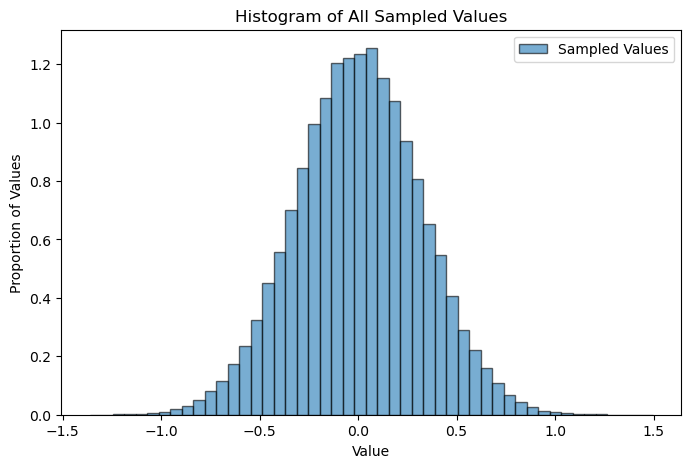

In [166]:
# plot histogram of all sampled values


# create figure
fig, ax = plt.subplots(figsize=(8, 5))

# histogram 
ax.hist(means_samples, bins=np.linspace(means_samples.min(), means_samples.max(),50), density=True, alpha=0.6, edgecolor='black', label="Sampled Values")


# label the axes and the plot
ax.set_xlabel("Value")
ax.set_ylabel("Proportion of Values")
ax.set_title("Histogram of All Sampled Values")
ax.legend()

plt.show()


We draw 100,000 samples, each containing 10 values from the [standard normal distribution](https://www.w3schools.com/statistics/statistics_standard_normal_distribution.php)

The histogram shows the distribution of the 1,000,000 individual values generated from a standard normal distribution (mean = 0, SD = 1). Since each of the 100,000 samples contains 10 values from the same normal distribution, flattening them produces a large set of normally distributed numbers. The underlying population we sampled from behaves like a standard normal distribution.

Because the data come from a Normal distribution with parameters $\mu = 0 $ (mean) and $\sigma^2 = 1 $ (standard deviation), the histogram of all sampled values shows the expected
characteristics of a standard normal distribution:


* Centered at 0  
* Most values fall between −0.5 and +0.5 
* Very few values occur beyond +1 and -1  
* Smooth tapering toward the extremes (tail behavior)

A large number of samples makes the histogram closely match the theoretical [bell curve](https://en.wikipedia.org/wiki/Normal_distribution).




This histogram is an empirical estimate of the [probability density function (PDF)](https://en.wikipedia.org/wiki/Normal_distribution) of the standard normal distribution.

$ f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}} $


The above mathematical function can be applied to python: 

In [167]:
def f(x, mu=0.0, sigma=1.0):
  # The normalisation constant.
  norm = 1.0 / np.sqrt(2.0 * np.pi * sigma**2)
  
  # f(x)
  return norm * np.exp(-(x - mu)**2 / (2.0 * sigma**2))

In [168]:
# Test the function.
f(0.0)

0.3989422804014327

In [194]:
# Create an x range.
x = np.linspace(means_samples.min(), means_samples.max(),100000)

# Get y values.
y = f(x, mu=0, sigma=1/np.sqrt(sample_size))


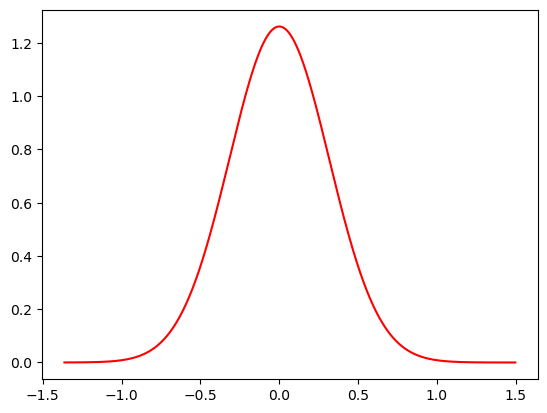

In [195]:
# Create an empty plot.
fig, ax = plt.subplots()

# Plot the function.
ax.plot(x, y, 'r');

Let's plot both together to see how they are overlapping. 

In [190]:
all_samples = np.random.normal(loc=0, scale=1, size=(num_samples, sample_size))

sd_sample = np.std(all_samples, axis=1, ddof=1)
sd_pop    = np.std(all_samples, axis=1, ddof=0)

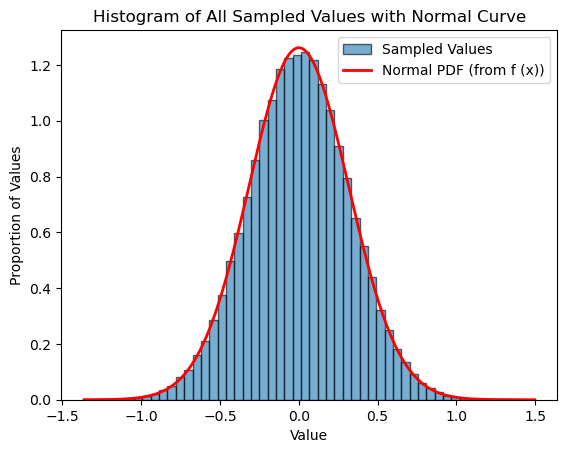

In [196]:

plt.hist(means_samples, bins=np.linspace(means_samples.min(), means_samples.max(), 55), density=True, alpha=0.6, edgecolor="black",
         label="Sampled Values")

# x range
x = np.linspace(means_samples.min(), means_samples.max(), 500)
# use the function f()  above
y = f(x, mu=0, sigma=1/np.sqrt(sample_size))

# bell curve 
plt.plot(x, y, 'r-', linewidth=2, label="Normal PDF (from f (x))")

# labels
plt.xlabel("Value")
plt.ylabel("Proportion of Values")
plt.title("Histogram of All Sampled Values with Normal Curve")

plt.legend()
plt.show()



We calculate the standard deviation for every one of the 100,000 samples using the two different formulas provided by the `ddof` [Delta Degrees of Freedom](https://medium.com/@caiocvelasco/degrees-of-freedom-part-2-a-brief-mathematical-introduction-8a8bf5d1dae7) parameter in [NumPy](https://numpy.org/).

DD-OF ${= 1}$ (Sample Standard Deviation) 

The **Sample Standard Deviation ($s$)** is based on an estimator of the variance that is [**unbiased**](https://www.geeksforgeeks.org/machine-learning/unbiased-estimator/), and therefore is typically closer to the true population standard deviation ($\sigma$) than the population SD computed with `ddof=0`, although the SD itself is still slightly biased. 


It uses $N-1$ in the denominator to correct for the tendency of $s$ to underestimate $\sigma$ when calculated from a sample.

`ddof` = 1 ->  Denominator is $N - 1$.

In [173]:
# Calculate Sample Standard Deviation (Sample SD) for all 100,000 samples.
# ddof=1 uses N-1 in the denominator (gives an unbiased estimator of the variance).
sample_sds = np.std(all_samples, axis=1, ddof=1) 



Let's look at the distribution of the Sample Standard Deviation (ddof=1). This allows us to see how it centers around the true value.

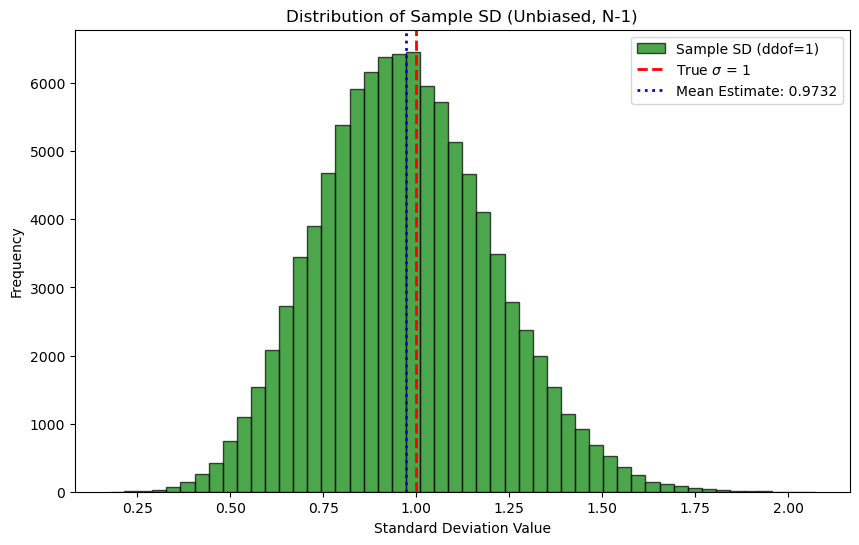

In [174]:
# Plotting histogram for Sample Standard Deviation (ddof=1)

plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(sample_sds, bins=50, alpha=0.7, color='green', edgecolor='black', label='Sample SD (ddof=1)')

# Plot vertical line for True Sigma (Calculated using 100% of the data in a population)
plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='True $\\sigma$ = 1')

# Plot vertical line for the Mean of the estimations
mean_sample = np.mean(sample_sds)
plt.axvline(mean_sample, color='blue', linestyle='dotted', linewidth=2, label=f'Mean Estimate: {mean_sample:.4f}')

plt.title('Distribution of Sample SD (Unbiased, N-1)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()



DD-OF $\text{= 0}$ (Population Standard Deviation)
The formula for the Population Standard Deviation ($\sigma$) uses $N$ in the denominator. When applied to a sample, this calculation is a biased estimator because it consistently underestimates the true population SD ($\sigma$).$\mathbf{ddof}=0 \rightarrow$ Denominator is $N$.

Now, let's look at the distribution Population Standard Deviation (Population SD) (ddof=0). 

In [175]:
# Calculate Population Standard Deviation (Population SD) for all 100,000 samples.
# ddof=0 uses N in the denominator (biased estimator when applied to a sample).
population_sds = np.std(all_samples, axis=1, ddof=0) 


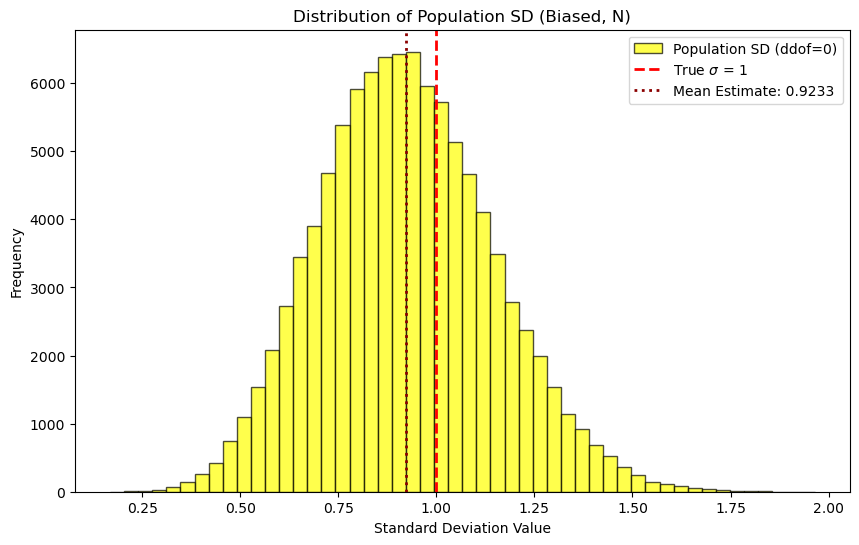

In [176]:
plt.figure(figsize=(10, 6))

# Plot histogram
plt.hist(population_sds, bins=50, alpha=0.7, color='yellow', edgecolor='black', label='Population SD (ddof=0)')

# Plot vertical line for True Sigma (Calculated using 100% of the data in a population)
plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='True $\\sigma$ = 1')

# Plot vertical line for the Mean of the estimations (average value of all the results)
mean_pop = np.mean(population_sds)
plt.axvline(mean_pop, color='darkred', linestyle='dotted', linewidth=2, label=f'Mean Estimate: {mean_pop:.4f}')

plt.title('Distribution of Population SD (Biased, N)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()



Now let's plot the distribution of the 100,000 computed SDs to visually compare the effect of using $N-1$ versus $N$.

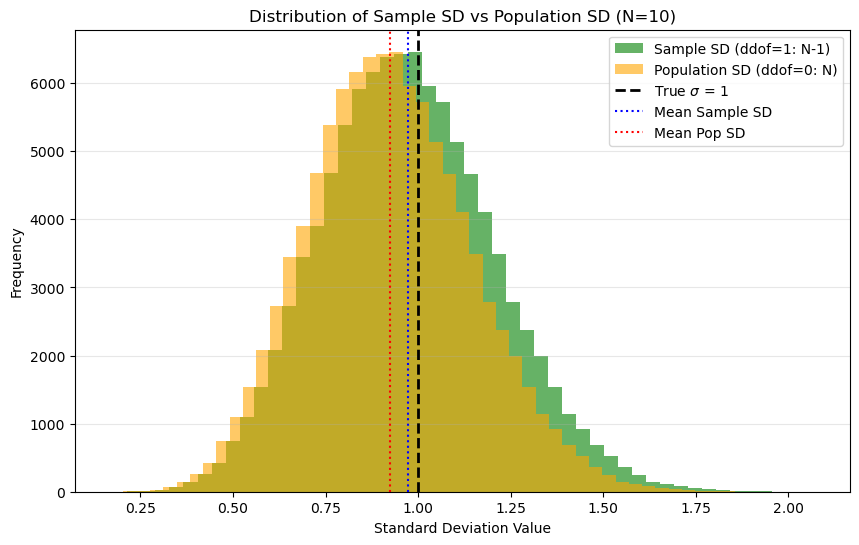

In [177]:
# Calculate SDs
sample_sds = np.std(all_samples, axis=1, ddof=1) # Unbiased-ish (N-1)
population_sds = np.std(all_samples, axis=1, ddof=0) # Biased (N)

# Create the figure
plt.figure(figsize=(10, 6))

# Plot Sample SD (ddof=1)
plt.hist(sample_sds, bins=50, alpha=0.6, color='green', label='Sample SD (ddof=1: N-1)')

# Plot Population SD (ddof=0)
plt.hist(population_sds, bins=50, alpha=0.6, color='orange', label='Population SD (ddof=0: N)')
# Vertical line for True Sigma
plt.axvline(1.0, color='k', linestyle='dashed', linewidth=2, label='True $\\sigma$ = 1')

# Add Mean lines to show the shift
plt.axvline(np.mean(sample_sds), color='blue', linestyle='dotted', label='Mean Sample SD')
plt.axvline(np.mean(population_sds), color='red', linestyle='dotted', label='Mean Pop SD')

plt.title('Distribution of Sample SD vs Population SD (N=10)')
plt.xlabel('Standard Deviation Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


Now, lets increase the sample sizes and see what happens. 

Large Sample (N=100) Results:
Sample SD Mean (ddof=1): 0.99786
Pop SD Mean    (ddof=0): 0.99286
Difference: 0.00500


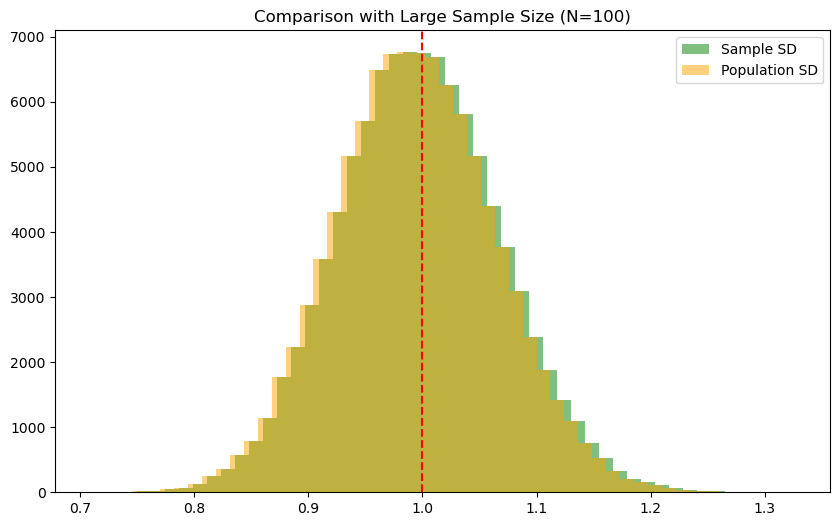

In [178]:
# Now test with a larger sample size 
# 100 data points per sample
N_large = 100
large_samples = np.random.normal(0, 1, size=(100000, N_large))

# Calculate SDs
s_large = np.std(large_samples, axis=1, ddof=1)
p_large = np.std(large_samples, axis=1, ddof=0)

print(f"Large Sample (N={N_large}) Results:")
print(f"Sample SD Mean (ddof=1): {np.mean(s_large):.5f}")
print(f"Pop SD Mean    (ddof=0): {np.mean(p_large):.5f}")
print(f"Difference: {np.mean(s_large) - np.mean(p_large):.5f}")

# Visualizing the Overlap
plt.figure(figsize=(10, 6))
plt.hist(s_large, bins=50, alpha=0.5, color='green', label='Sample SD')
plt.hist(p_large, bins=50, alpha=0.5, color='orange', label='Population SD')
plt.title(f'Comparison with Large Sample Size (N={N_large})')
plt.axvline(1.0, color='red', linestyle='--')
plt.legend()
plt.show()

Now test with an extra large sample size. 

Large Sample (N=1000) Results:
Sample SD Mean (ddof=1): 0.99975
Pop SD Mean    (ddof=0): 0.99925
Difference: 0.00050


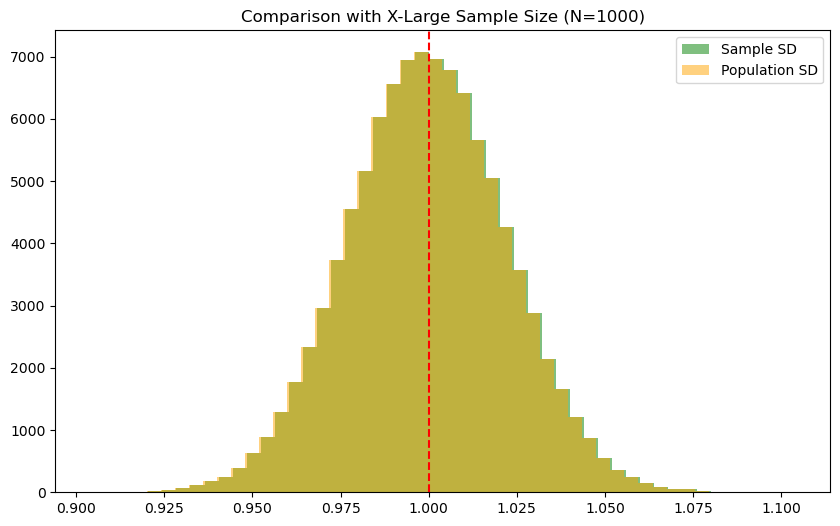

In [179]:

# 1000 data points per sample
N_Xlarge = 1000
large_samples = np.random.normal(0, 1, size=(100000, N_Xlarge))

# Calculate SDs
s_Xlarge = np.std(large_samples, axis=1, ddof=1)
p_Xlarge = np.std(large_samples, axis=1, ddof=0)

print(f"Large Sample (N={N_Xlarge}) Results:")
print(f"Sample SD Mean (ddof=1): {np.mean(s_Xlarge):.5f}")
print(f"Pop SD Mean    (ddof=0): {np.mean(p_Xlarge):.5f}")
print(f"Difference: {np.mean(s_Xlarge) - np.mean(p_Xlarge):.5f}")

# Visualizing the Overlap
plt.figure(figsize=(10, 6))
plt.hist(s_Xlarge, bins=50, alpha=0.5, color='green', label='Sample SD')
plt.hist(p_Xlarge, bins=50, alpha=0.5, color='orange', label='Population SD')
plt.title(f'Comparison with X-Large Sample Size (N={N_Xlarge})')
plt.axvline(1.0, color='red', linestyle='--')
plt.legend()
plt.show()

### Summary

Observed Differences in Histograms

---

When observing the plot, the key difference is the central tendency of the two distributions:

Population SD (ddof=0): This distribution is moved slightly to the left (lower values). Its mean is less than the true population standard deviation ($\sigma=1$). 

This demonstrates that using $N$ in the denominator results in a biased estimator that keeps underestimating the true population SD when applied to small samples.

Sample SD `ddof=1`: This distribution is shifted slightly to the right (higher values) compared to the `ddof=0` distribution. 

Its mean is much closer to the true population standard deviation ($\sigma=1$). 

This confirms that the [Bessel's correction](https://www.geeksforgeeks.org/machine-learning/bessels-correction/) (using $N-1$) reduces the bias in the SD estimate (and makes the variance estimate unbiased).  

For more explanation see the youtube video [here](https://www.youtube.com/watch?v=E3_408q1mjo)



Expected Changes with Increased Sample Size ($N$)

If we significantly increase the sample size from $N=10$ to $N=1000$, we expect two major changes in the plots:

**The Two Histograms Will Merge (Bias Disappears)**
The only difference between the two calculations is whether we divide by **$N$** (Population formula) or **$N-1$** (Sample formula).
* **Small Sample ($N=10$):** Dividing by 10 versus 9 makes a big difference (about 11%). This pushes the histograms apart.
* **Large Sample ($N=1000$):** Dividing by 1000 versus 999 makes almost no difference ( as only about 0.1%).

Because the mathematical difference becomes tiny, the "Population SD" histogram will slide over and sit almost perfectly on top of the "Sample SD" histogram.


Using more data ($N=1000$) makes the math correction ($N-1$) less important, and the estimates become more precise.

## Problem 3: t-Tests

A type II error occurs when a test fails to reject the null hypothesis even though it is false. For each mean difference
$ d =0,0.1,0.2,…,1.0 $, repeat the following simulation 1,000 times:


* Draw two samples of size 100, one from the standard normal distribution and one from the normal distribution with mean $d$ and standard deviation 1.
* Run an independent samples t-test on the two samples, rejecting the null hypothesis if the p-value is less than 0.05.
* Record the proportion of times the null hypothesis is not rejected.


Plot this proportion against $d$, and explain how the type II error rate changes as the difference in means increases.

## Problem 4: ANOVA

Generate three independent samples, each of size 30, from normal distributions with means 0, 0.5, and 1, each with standard deviation 1.

* Perform a one-way ANOVA to test whether all three means are equal.
* Perform three independent two-sample t-tests: samples 1 vs 2, 1 vs 3, and 2 vs 3.
* Compare the conclusions.

Write a short note on why ANOVA is preferred over running several t-tests.

*This analysis is based on material from the Applied Statistics module of the Higher Diploma in Data Analytics, along with additional referenced online sources.*

***
End